# Weekly FPL analysis

Thin notebook: all logic lives in `src/fpl`. This just calls the pipeline and inspects results.

## 1. Update data (scrape + references + stats)

Equivalent to running `python scripts/update_data.py`.

In [1]:
from fpl.scrape import understat
from fpl.reference import refresh as refresh_references
from fpl.stats import player_stats, team_gsxg

understat.run()
refresh_references.run()
player_stats.run()
team_gsxg.run()

No new Understat data for EPL 2026/2027
Teams: 20
Current FPL players matched to Understat history: 486
Players without a match: 58 (see C:\Users\colin\OneDrive\Documents\Data_Analysis\FPL\fpl-2627\data\unmatched_understat_names.csv)
Recalculated stats for 544 players
Recalculated GSxG factors for 20 teams


In [3]:
from fpl import db

db.init_db()

In [4]:
# Cell 2 — load what's already in the DB rather than re-scraping/re-running
# the full pipeline every time you just want to sense-check outputs
gsxg = db.read_table("gsxg")
gsxg_avg = db.read_table("gsxg_avg")
player_stats = db.read_table("understat_player_stats")

gsxg['team'].unique()

<StringArray>
[          'Arsenal',       'Aston Villa',       'Bournemouth',
         'Brentford',          'Brighton',           'Chelsea',
    'Crystal Palace',           'Everton',            'Fulham',
             'Leeds',         'Liverpool',   'Manchester City',
 'Manchester United',  'Newcastle United', 'Nottingham Forest',
        'Sunderland',         'Tottenham',          'Coventry',
              'Hull',           'Ipswich']
Length: 20, dtype: str

In [5]:
gsxg[gsxg['team'] == 'Manchester City']

,team,h_a,gamestate,xg_factor,xgc_factor
66,Manchester City,h,Winning,1.040990,0.690443
67,Manchester City,h,Draw,1.826509,0.769361
68,Manchester City,h,Losing,1.056548,1.049030
69,Manchester City,a,Winning,1.294187,0.784529
70,Manchester City,a,Draw,1.378463,1.004015
71,Manchester City,a,Losing,0.953031,0.623452


In [6]:
gsxg_team_avg = gsxg[['team', 'xg_factor', 'xgc_factor']].groupby('team').mean()
gsxg_team_avg.sort_values(by='xg_factor', ascending=False)

,xg_factor,xgc_factor
team,,
Manchester City,1.258288,0.820138
Arsenal,1.168640,0.739593
Chelsea,1.127437,0.995175
Liverpool,1.121200,0.999930
Manchester United,1.109271,0.875056
Brentford,1.089643,0.979438
Brighton,1.024472,0.811682
Crystal Palace,1.002145,0.997381
Nottingham Forest,0.996312,0.970658


In [7]:
gsxg_team_avg.sort_values(by='xgc_factor', ascending=True)

,xg_factor,xgc_factor
team,,
Arsenal,1.168640,0.739593
Brighton,1.024472,0.811682
Manchester City,1.258288,0.820138
Manchester United,1.109271,0.875056
Leeds,0.937914,0.883105
Sunderland,0.837625,0.925400
Tottenham,0.818553,0.941305
Nottingham Forest,0.996312,0.970658
Brentford,1.089643,0.979438


In [8]:
gsxg_avg

,h_a,gamestate,avg_xg_min,avg_xgc_min
0,a,Draw,0.018270,0.017802
1,a,Losing,0.013886,0.019433
2,a,Winning,0.019660,0.014126
3,h,Draw,0.019839,0.019564
4,h,Losing,0.014911,0.024872
5,h,Winning,0.025000,0.015492


In [9]:
# Cell 3 — quick plausibility checks before touching the simulator at all
# xg_factor/xgc_factor should cluster around 1.0 league-wide
gsxg[["xg_factor", "xgc_factor"]].describe()

,xg_factor,xgc_factor
count,120.000000,120.000000
mean,0.973813,0.971122
std,0.250059,0.224774
min,0.390600,0.401244
25%,0.824955,0.842078
50%,0.945413,0.973346
75%,1.096353,1.086178
max,1.826509,1.620970


## 2. Simulate upcoming gameweeks

In [10]:
from fpl.simulate import engine

N_SIMULATIONS = 1000  # increase for more stable estimates, at the cost of runtime
N_GAMEWEEKS = 5

results = engine.simulate_next_gameweeks(n_simulations=N_SIMULATIONS, n_gameweeks=N_GAMEWEEKS)
gameweek_ids = sorted(results)
gameweek_ids


Simulating Gameweek 3
Simulating Ipswich Town vs. Liverpool
Simulating Newcastle vs. Bournemouth
Simulating Brentford vs. Sunderland
Simulating Brighton vs. Leeds
Simulating Fulham vs. Crystal Palace
Simulating Man City vs. Coventry City
Simulating Nott'm Forest vs. Spurs
Simulating Hull City vs. Aston Villa
Simulating Everton vs. Man Utd
Simulating Arsenal vs. Chelsea

Simulating Gameweek 4
Simulating Liverpool vs. Fulham
Simulating Crystal Palace vs. Ipswich Town
Simulating Bournemouth vs. Brentford
Simulating Aston Villa vs. Nott'm Forest
Simulating Chelsea vs. Hull City
Simulating Spurs vs. Everton
Simulating Sunderland vs. Arsenal
Simulating Coventry City vs. Brighton
Simulating Man Utd vs. Man City
Simulating Leeds vs. Newcastle

Simulating Gameweek 5
Simulating Brentford vs. Chelsea
Simulating Spurs vs. Aston Villa
Simulating Newcastle vs. Hull City
Simulating Leeds vs. Crystal Palace
Simulating Brighton vs. Arsenal
Simulating Everton vs. Ipswich Town
Simulating Nott'm Forest v

[np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]

### Sense-check: top predicted scorers per gameweek

In [11]:
# Cell 5 — top predicted scorers, for a first gut check against reality
gw_stats, scorelines = results[gameweek_ids[0]]
gw_stats.sort_values("points", ascending=False).head(15)

,minutes,goals,assists,clean_sheet,saves,goals_conceded,yellow_cards,red_cards,points
player,,,,,,,,,
Rayan Cherki,67.596,0.425,0.637,0.283,0.0,0.659,0.085,0.0,5.776
Nico O'Reilly,66.567,0.348,0.199,0.309,0.0,0.627,0.075,0.0,5.233
Erling Haaland,70.232,0.789,0.085,0.355,0.0,0.640,0.072,0.0,4.955
Maxim De Cuyper,58.388,0.339,0.350,0.183,0.0,0.753,0.000,0.0,4.927
Semi Ajayi,70.884,0.449,0.000,0.185,0.0,1.127,0.000,0.0,4.662
Phil Foden,62.275,0.250,0.562,0.249,0.0,0.584,0.102,0.0,4.513
Dango Ouattara,66.613,0.319,0.436,0.149,0.0,1.059,0.078,0.0,4.483
Bruno Borges Fernandes,67.077,0.201,0.618,0.200,0.0,0.941,0.138,0.0,4.475
Dominik Szoboszlai,71.824,0.211,0.529,0.189,0.0,1.292,0.121,0.0,4.377


In [12]:
# Cell — scoreline heatmap helper
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def scoreline_heatmap(scorelines, home_team, away_team, max_goals=5):
    """Heatmap of P(home_goals, away_goals) for one fixture.

    scorelines: the dict returned alongside gw_stats from simulate_next_gameweeks,
    keyed by (home_team, away_team) -> {(home_goals, away_goals): probability}.
    Scores above max_goals are bucketed into a "N+" row/column so the
    displayed probabilities still sum to (close to) 100%.
    """
    probs = scorelines[(home_team, away_team)]

    df = pd.Series(probs).rename_axis(["home_goals", "away_goals"]).reset_index(name="prob")
    df["home_goals"] = df["home_goals"].clip(upper=max_goals)
    df["away_goals"] = df["away_goals"].clip(upper=max_goals)
    grid = df.groupby(["home_goals", "away_goals"])["prob"].sum().unstack(fill_value=0)
    grid = grid.reindex(index=range(max_goals + 1), columns=range(max_goals + 1), fill_value=0)

    labels = [str(i) for i in range(max_goals)] + [f"{max_goals}+"]
    grid.index = labels
    grid.columns = labels

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(grid, annot=True, fmt=".1%", cmap="viridis",
                cbar_kws={"label": "Probability"}, ax=ax)
    ax.set_xlabel(f"{away_team} goals")
    ax.set_ylabel(f"{home_team} goals")
    ax.set_title(f"{home_team} vs {away_team} — scoreline probabilities\n"
                 f"(covers {df['prob'].sum():.1%} of simulated outcomes)")
    ax.invert_yaxis()  # 0 goals at the bottom, like a normal grid
    
    # Calculate result probabilities
    home_win_prob = sum(prob for (h, a), prob in probs.items() if h > a)
    draw_prob = sum(prob for (h, a), prob in probs.items() if h == a)
    away_win_prob = sum(prob for (h, a), prob in probs.items() if h < a)
    
    probabilities = {
        "home_win": home_win_prob,
        "draw": draw_prob,
        "away_win": away_win_prob
    }
    
    return ax, probabilities

In [13]:
# Cell — use it
gw_stats, scorelines = results[gameweek_ids[1]]

# check the exact team-name strings used as keys before calling the function
list(scorelines.keys())

[('Liverpool', 'Fulham'),
 ('Crystal Palace', 'Ipswich Town'),
 ('Bournemouth', 'Brentford'),
 ('Aston Villa', "Nott'm Forest"),
 ('Chelsea', 'Hull City'),
 ('Spurs', 'Everton'),
 ('Sunderland', 'Arsenal'),
 ('Coventry City', 'Brighton'),
 ('Man Utd', 'Man City'),
 ('Leeds', 'Newcastle')]

{'home_win': 0.441, 'draw': 0.13899999999999998, 'away_win': 0.42}

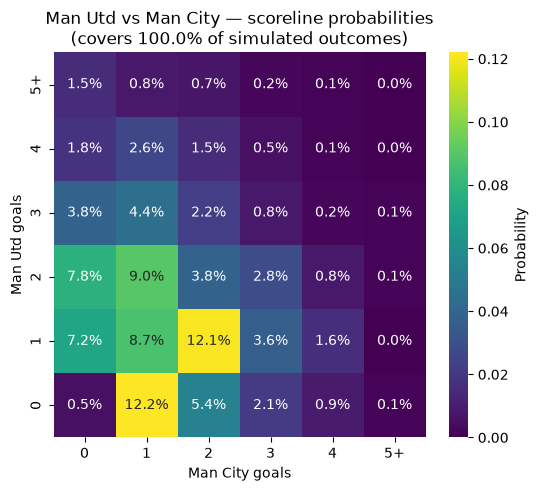

In [14]:
# Cell — plot one fixture
home_team = 'Man Utd'
away_team = 'Man City'

ax, probabilities = scoreline_heatmap(scorelines, home_team, away_team, max_goals=5)

probabilities

In [15]:
for gw_id in gameweek_ids:
    print(f"\nGameweek {gw_id}")
    display(results[gw_id][0].sort_values("points", ascending=False).head(10))


Gameweek 3


,minutes,goals,assists,clean_sheet,saves,goals_conceded,yellow_cards,red_cards,points
player,,,,,,,,,
Rayan Cherki,67.596,0.425,0.637,0.283,0.0,0.659,0.085,0.0,5.776
Nico O'Reilly,66.567,0.348,0.199,0.309,0.0,0.627,0.075,0.0,5.233
Erling Haaland,70.232,0.789,0.085,0.355,0.0,0.640,0.072,0.0,4.955
Maxim De Cuyper,58.388,0.339,0.350,0.183,0.0,0.753,0.000,0.0,4.927
Semi Ajayi,70.884,0.449,0.000,0.185,0.0,1.127,0.000,0.0,4.662
Phil Foden,62.275,0.250,0.562,0.249,0.0,0.584,0.102,0.0,4.513
Dango Ouattara,66.613,0.319,0.436,0.149,0.0,1.059,0.078,0.0,4.483
Bruno Borges Fernandes,67.077,0.201,0.618,0.200,0.0,0.941,0.138,0.0,4.475
Dominik Szoboszlai,71.824,0.211,0.529,0.189,0.0,1.292,0.121,0.0,4.377



Gameweek 4


,minutes,goals,assists,clean_sheet,saves,goals_conceded,yellow_cards,red_cards,points
player,,,,,,,,,
Morgan Gibbs-White,64.671,0.552,0.219,0.215,0.0,1.010,0.000,0.0,5.098
Maxim De Cuyper,58.425,0.265,0.295,0.216,0.0,0.739,0.000,0.0,4.474
Dominic Calvert-Lewin,66.790,0.725,0.000,0.356,0.0,0.488,0.160,0.0,4.302
Bruno Borges Fernandes,68.121,0.195,0.576,0.155,0.0,1.040,0.137,0.0,4.296
Dominik Szoboszlai,73.267,0.185,0.457,0.253,0.0,0.877,0.130,0.0,4.082
Cole Palmer,61.801,0.341,0.206,0.255,0.0,0.569,0.063,0.0,3.964
Bryan Mbeumo,63.037,0.426,0.090,0.136,0.0,0.957,0.058,0.0,3.928
Ollie Watkins,69.084,0.589,0.076,0.121,0.0,1.557,0.235,0.0,3.923
Cody Gakpo,71.379,0.290,0.233,0.228,0.0,0.879,0.078,0.0,3.922



Gameweek 5


,minutes,goals,assists,clean_sheet,saves,goals_conceded,yellow_cards,red_cards,points
player,,,,,,,,,
Rayan Cherki,66.232,0.356,0.551,0.246,0.0,0.730,0.082,0.0,5.105
Dango Ouattara,66.498,0.376,0.464,0.112,0.0,1.439,0.084,0.0,4.811
Marcus Tavernier,75.280,0.477,0.267,0.063,0.0,1.890,0.244,0.0,4.713
Dominik Szoboszlai,72.421,0.237,0.613,0.135,0.0,1.618,0.126,0.0,4.682
Nico O'Reilly,66.925,0.288,0.148,0.269,0.0,0.714,0.082,0.0,4.538
Erling Haaland,70.100,0.675,0.074,0.304,0.0,0.753,0.073,0.0,4.467
Igor Thiago Nascimento Rodrigues,68.588,0.664,0.063,0.125,0.0,1.498,0.061,0.0,4.383
Morgan Gibbs-White,66.509,0.437,0.154,0.208,0.0,1.038,0.000,0.0,4.369
Harvey Barnes,64.201,0.447,0.144,0.238,0.0,0.604,0.000,0.0,4.365



Gameweek 6


,minutes,goals,assists,clean_sheet,saves,goals_conceded,yellow_cards,red_cards,points
player,,,,,,,,,
Loum Tchaouna,60.306,0.351,0.543,0.226,0.0,0.633,0.084,0.0,4.948
Semi Ajayi,72.099,0.502,0.000,0.159,0.0,1.191,0.000,0.0,4.883
Jack Rudoni,55.779,0.550,0.180,0.172,0.0,0.597,0.000,0.0,4.770
Bruno Borges Fernandes,67.672,0.205,0.680,0.230,0.0,0.771,0.138,0.0,4.724
Taiwo Awoniyi,47.339,0.875,0.081,0.139,0.0,0.481,0.169,0.0,4.711
Bryan Mbeumo,63.428,0.510,0.132,0.187,0.0,0.724,0.080,0.0,4.512
Morgan Gibbs-White,64.762,0.462,0.183,0.164,0.0,1.077,0.000,0.0,4.485
Rayan Cherki,66.307,0.292,0.463,0.152,0.0,0.983,0.092,0.0,4.418
Saša Lukić,70.779,0.249,0.532,0.173,0.0,1.082,0.298,0.0,4.357



Gameweek 7


,minutes,goals,assists,clean_sheet,saves,goals_conceded,yellow_cards,red_cards,points
player,,,,,,,,,
Rayan Cherki,64.924,0.404,0.698,0.306,0.0,0.580,0.103,0.0,5.801
Nico O'Reilly,66.855,0.384,0.202,0.345,0.0,0.575,0.080,0.0,5.614
Maxim De Cuyper,56.725,0.406,0.463,0.156,0.0,0.769,0.000,0.0,5.544
Erling Haaland,71.224,0.874,0.094,0.375,0.0,0.641,0.077,0.0,5.341
Diego Gómez Amarilla,66.403,0.514,0.327,0.200,0.0,0.941,0.311,0.0,4.942
Phil Foden,61.755,0.301,0.580,0.279,0.0,0.556,0.111,0.0,4.834
Dango Ouattara,66.385,0.351,0.482,0.082,0.0,1.525,0.079,0.0,4.722
Igor Thiago Nascimento Rodrigues,68.722,0.724,0.053,0.065,0.0,1.593,0.060,0.0,4.579
Marc Guéhi,71.035,0.221,0.122,0.353,0.0,0.667,0.079,0.0,4.469


## 3. Optimise squad

In [ ]:
from fpl.squad import optimize

optimize.run()